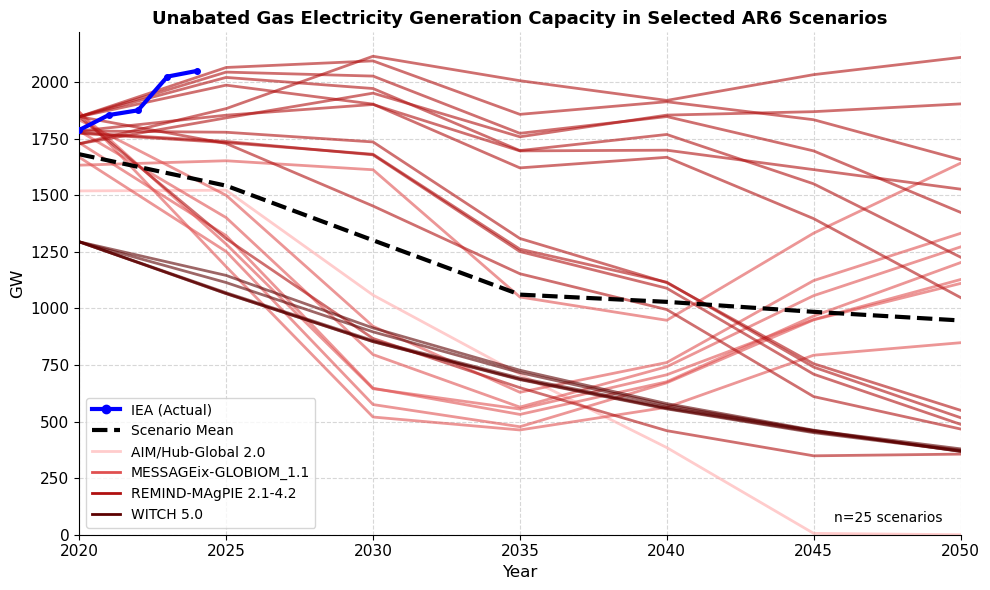

In [33]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.lines import Line2D

# --- Constants ---
FIG_SIZE = (10, 6)
LINE_WIDTH = 2
SCENARIO_ALPHA = 0.6
GREY_MIX_RATIO = 0.0
MEAN_COLOR = 'black'
MEAN_ALPHA = 1.0
X_START, X_END = 2020, 2050
SHOW_SHADED_REGION = False
SHADING_COLOR = 'gray'
SHADING_ALPHA = 0.15

# All possible year columns in the CSV
years_str_all = ['2020', '2021', '2022', '2023', '2024', '2025', '2030', '2035', '2040', '2045', '2050']
# Desired ticks on the axis - every 5 years
ticks_years = [2020, 2025, 2030, 2035, 2040, 2045, 2050]

def get_greyed_color(color, alpha=1.0, mix_ratio=0.0):
    rgb = mcolors.to_rgb(color)
    greyed_rgb = tuple((1 - mix_ratio) * c + mix_ratio * 0.75 for c in rgb)
    return greyed_rgb + (alpha,)

MODEL_COLORS = {
    'AIM/Hub-Global 2.0':        '#FFAAAA',
    'MESSAGEix-GLOBIOM_1.1':     '#E05050',
    'REMIND-MAgPIE 2.1-4.2':     '#B01010',
    'WITCH 5.0':                 '#5C0000',
    'IEA':                       '#0000FF'
}

# --- Data Loading ---
df = pd.read_csv('gas_wo_CCS_ACTUAL.csv')

# Separate IEA from AR6 scenarios
scenarios_df = df[df['Model'] != 'IEA']
iea_df = df[df['Model'] == 'IEA']
model_counts = scenarios_df['Model'].value_counts().to_dict()

plt.figure(figsize=FIG_SIZE)

# --- Plotting Scenarios ---
# .dropna() connects 2020 to 2025 directly if interim years are missing
for idx, row in scenarios_df.iterrows():
    model_name = row['Model']
    base_color = MODEL_COLORS.get(model_name, '#7f7f7f')
    line_color = get_greyed_color(base_color, alpha=SCENARIO_ALPHA, mix_ratio=GREY_MIX_RATIO)
    
    series = row[years_str_all].dropna()
    plt.plot(series.index.astype(int), series.values, color=line_color, linewidth=LINE_WIDTH, zorder=2, label='_nolegend_')

# --- Plotting IEA Actuals ---
for idx, row in iea_df.iterrows():
    series = row[years_str_all].dropna()
    plt.plot(series.index.astype(int), series.values, color=MODEL_COLORS['IEA'], linewidth=3, 
             marker='o', markersize=4, zorder=15, label='_nolegend_')

# --- Plotting Mean of Scenarios ---
mean_years = ['2020', '2025', '2030', '2035', '2040', '2045', '2050']
overall_mean = scenarios_df[mean_years].mean()
plt.plot(overall_mean.index.astype(int), overall_mean.values, color=MEAN_COLOR, linewidth=3, alpha=MEAN_ALPHA,
         zorder=10, label='_nolegend_', linestyle="--")

# --- Legend Setup ---
legend_elements = [
    Line2D([0], [0], color=MODEL_COLORS['IEA'], lw=3, marker='o', label='IEA (Actual)'),
    Line2D([0], [0], color=MEAN_COLOR, lw=3, alpha=MEAN_ALPHA, label='Scenario Mean', linestyle="--")
]
for model in MODEL_COLORS:
    if model != 'IEA' and model in scenarios_df['Model'].unique():
        n = model_counts.get(model, 1)
        swatch_alpha = min(SCENARIO_ALPHA * n, 1.0)
        swatch_color = get_greyed_color(MODEL_COLORS[model], alpha=swatch_alpha, mix_ratio=GREY_MIX_RATIO)
        legend_elements.append(Line2D([0], [0], color=swatch_color, lw=LINE_WIDTH, label=model))

# --- Formatting ---
unit = df['Unit'].iloc[0]
plt.title('Unabated Gas Electricity Generation Capacity in Selected AR6 Scenarios', fontsize=13, fontweight='bold')
plt.xlabel('Year', fontsize=12)
plt.ylabel(unit, fontsize=12)

# Specific X-ticks only every 5 years
plt.xticks(ticks_years, fontsize=11)
plt.yticks(fontsize=11)
plt.xlim(X_START, X_END)
plt.ylim(bottom=0)
plt.grid(True, linestyle='--', alpha=0.5)

plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

plt.legend(handles=legend_elements, loc='lower left', fontsize=10)
# Change the n= annotation to consistent position
plt.annotate(f'n={len(scenarios_df)} scenarios', xy=(0.98, 0.02), xycoords='axes fraction',
             fontsize=10, color='black', ha='right', va='bottom')

plt.tight_layout()
plt.savefig('gas_unabated_capacity_fixed.svg', format='svg', bbox_inches='tight', transparent=True)
plt.show()

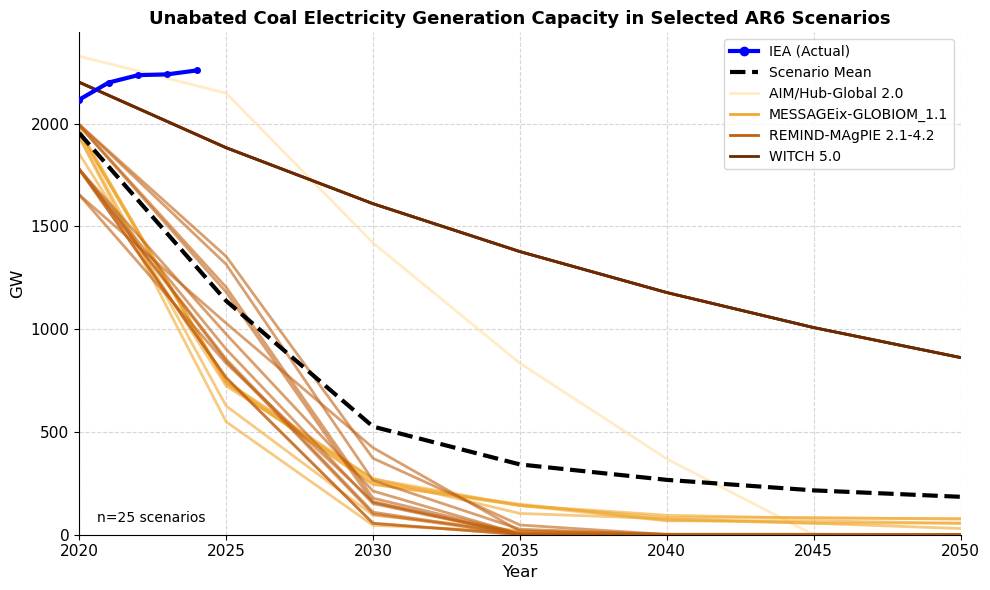

In [34]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.lines import Line2D
import matplotlib.patches as mpatches

# --- Constants ---
FIG_SIZE = (10, 6)
LINE_WIDTH = 2
SCENARIO_ALPHA = 0.6
GREY_MIX_RATIO = 0.0
MEAN_COLOR = 'black'
MEAN_ALPHA = 1.0
X_START, X_END = 2020, 2050
SHOW_SHADED_REGION = False
SHADING_COLOR = 'gray'
SHADING_ALPHA = 0.15

# All possible year columns (including the new actuals)
years_str_all = ['2020', '2021', '2022', '2023', '2024', '2025', '2030', '2035', '2040', '2045', '2050']
# Desired ticks on the axis - every 5 years
ticks_years = [2020, 2025, 2030, 2035, 2040, 2045, 2050]

def get_greyed_color(color, alpha=1.0, mix_ratio=0.0):
    rgb = mcolors.to_rgb(color)
    greyed_rgb = tuple((1 - mix_ratio) * c + mix_ratio * 0.75 for c in rgb)
    return greyed_rgb + (alpha,)

MODEL_COLORS = {
    'AIM/Hub-Global 2.0':        '#FFE0A0',
    'MESSAGEix-GLOBIOM_1.1':     '#F0A830',
    'REMIND-MAgPIE 2.1-4.2':     '#C06010',
    'WITCH 5.0':                 '#6B2800',
    'IEA':                       '#0000FF' # Added Blue for IEA Actuals
}

# --- Data Loading ---
# Updated to use the 'ACTUAL' version of the CSV
df = pd.read_csv('coal_wo_CCS_ACTUAL.csv')

# Separate IEA actuals from AR6 scenarios for statistics
scenarios_df = df[df['Model'] != 'IEA']
iea_df = df[df['Model'] == 'IEA']
model_counts = scenarios_df['Model'].value_counts().to_dict()

plt.figure(figsize=FIG_SIZE)

# --- Plotting Scenarios ---
if SHOW_SHADED_REGION:
    p25 = scenarios_df[ticks_years].quantile(0.25)
    p75 = scenarios_df[ticks_years].quantile(0.75)
    plt.fill_between(ticks_years, p25, p75, color=SHADING_COLOR, alpha=SHADING_ALPHA, zorder=1)

for idx, row in scenarios_df.iterrows():
    model_name = row['Model']
    base_color = MODEL_COLORS.get(model_name, '#7f7f7f')
    line_color = get_greyed_color(base_color, alpha=SCENARIO_ALPHA, mix_ratio=GREY_MIX_RATIO)
    
    # .dropna() ensures the line connects 2020 directly to 2025 where data is missing
    series = row[years_str_all].dropna()
    plt.plot(series.index.astype(int), series.values, color=line_color, linewidth=LINE_WIDTH, zorder=2, label='_nolegend_')

# --- Plotting IEA Actuals ---
for idx, row in iea_df.iterrows():
    series = row[years_str_all].dropna()
    plt.plot(series.index.astype(int), series.values, color=MODEL_COLORS['IEA'], linewidth=3, 
             marker='o', markersize=4, zorder=15, label='_nolegend_')

# --- Plotting Mean of Scenarios ---
# Only use the major 5-year intervals for the mean line
overall_mean = scenarios_df[[str(y) for y in ticks_years]].mean()
plt.plot(ticks_years, overall_mean.values, color=MEAN_COLOR, linewidth=3, alpha=MEAN_ALPHA,
         zorder=10, label='_nolegend_', linestyle="--")

# --- Legend Setup ---
legend_elements = [
    Line2D([0], [0], color=MODEL_COLORS['IEA'], lw=3, marker='o', label='IEA (Actual)'),
    Line2D([0], [0], color=MEAN_COLOR, lw=3, alpha=MEAN_ALPHA, label='Scenario Mean', linestyle="--")
]

for model in MODEL_COLORS:
    if model != 'IEA' and model in scenarios_df['Model'].unique():
        n = model_counts.get(model, 1)
        swatch_alpha = min(SCENARIO_ALPHA * n, 1.0)
        swatch_color = get_greyed_color(MODEL_COLORS[model], alpha=swatch_alpha, mix_ratio=GREY_MIX_RATIO)
        legend_elements.append(Line2D([0], [0], color=swatch_color, lw=LINE_WIDTH, label=model))

if SHOW_SHADED_REGION:
    legend_elements.append(mpatches.Patch(color=SHADING_COLOR, alpha=SHADING_ALPHA, label='25th-75th Percentile'))

# --- Formatting ---
unit = df['Unit'].iloc[0]
plt.title('Unabated Coal Electricity Generation Capacity in Selected AR6 Scenarios', fontsize=13, fontweight='bold')
plt.xlabel('Year', fontsize=12)
plt.ylabel(unit, fontsize=12)

# Specific X-ticks only every 5 years as requested
plt.xticks(ticks_years, fontsize=11)
plt.yticks(fontsize=11)
plt.xlim(X_START, X_END)
plt.ylim(bottom=0)
plt.grid(True, linestyle='--', alpha=0.5)

plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

# Positioned legend upper right for coal (as it generally trends downward)
plt.legend(handles=legend_elements, loc='upper right', fontsize=10)
# Change the n= annotation to consistent position  
plt.annotate(f'n={len(scenarios_df)} scenarios', xy=(0.02, 0.02), xycoords='axes fraction',
             fontsize=10, color='black', ha='left', va='bottom')

plt.tight_layout()
plt.savefig('coal_unabated_capacity_fixed.svg', format='svg', bbox_inches='tight', transparent=True)

plt.show()

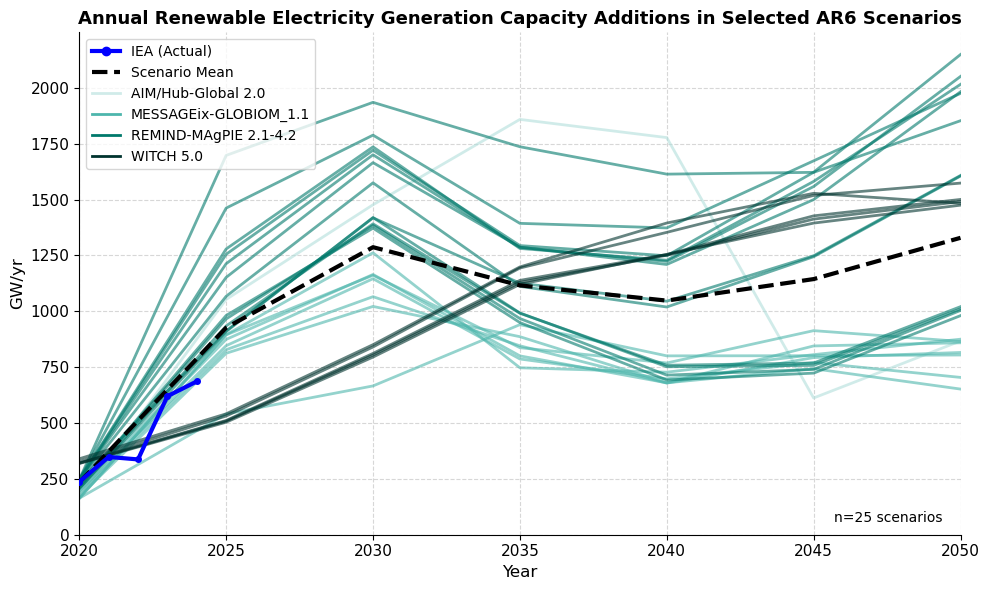

In [48]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.lines import Line2D
import matplotlib.patches as mpatches

# --- Constants ---
FIG_SIZE = (10, 6)
LINE_WIDTH = 2
SCENARIO_ALPHA = 0.6
GREY_MIX_RATIO = 0.0
MEAN_COLOR = 'black'
MEAN_ALPHA = 1.0
X_START, X_END = 2020, 2050
SHOW_SHADED_REGION = False
SHADING_COLOR = 'gray'
SHADING_ALPHA = 0.15

# All possible year columns (including the interim IEA years)
years_str_all = ['2020', '2021', '2022', '2023', '2024', '2025', '2030', '2035', '2040', '2045', '2050']
# Ticks set to every 5 years
ticks_years = [2020, 2025, 2030, 2035, 2040, 2045, 2050]

def get_greyed_color(color, alpha=1.0, mix_ratio=0.0):
    rgb = mcolors.to_rgb(color)
    greyed_rgb = tuple((1 - mix_ratio) * c + mix_ratio * 0.75 for c in rgb)
    return greyed_rgb + (alpha,)

MODEL_COLORS = {
    'AIM/Hub-Global 2.0':        '#B2DFDB',
    'MESSAGEix-GLOBIOM_1.1':     '#4DB6AC',
    'REMIND-MAgPIE 2.1-4.2':     '#00796B',
    'WITCH 5.0':                 '#00332E',
    'IEA':                       '#0000FF' # Blue for the Actuals
}

# --- Data Loading ---
# Note: Ensure your CSV is named RE_additions_ACTUAL.csv or update this line
df = pd.read_csv('RE_additions_ACTUAL.csv')

# Separate IEA from the scenarios
scenarios_df = df[df['Model'] != 'IEA']
iea_df = df[df['Model'] == 'IEA']
model_counts = scenarios_df['Model'].value_counts().to_dict()

plt.figure(figsize=FIG_SIZE)

# --- Plotting Scenarios ---
if SHOW_SHADED_REGION:
    # Use only major years for shading
    p25 = scenarios_df[[str(y) for y in ticks_years]].quantile(0.25)
    p75 = scenarios_df[[str(y) for y in ticks_years]].quantile(0.75)
    plt.fill_between(ticks_years, p25, p75, color=SHADING_COLOR, alpha=SHADING_ALPHA, zorder=1)

for idx, row in scenarios_df.iterrows():
    model_name = row['Model']
    base_color = MODEL_COLORS.get(model_name, '#7f7f7f')
    line_color = get_greyed_color(base_color, alpha=SCENARIO_ALPHA, mix_ratio=GREY_MIX_RATIO)
    
    # dropna() allows the line to jump from 2020 to 2025 for scenarios
    series = row[years_str_all].dropna()
    plt.plot(series.index.astype(int), series.values, color=line_color, linewidth=LINE_WIDTH, zorder=2, label='_nolegend_')

# --- Plotting IEA Actuals ---
for idx, row in iea_df.iterrows():
    series = row[years_str_all].dropna()
    plt.plot(series.index.astype(int), series.values, color=MODEL_COLORS['IEA'], linewidth=3, 
             marker='o', markersize=4, zorder=15, label='_nolegend_')

# --- Plotting Mean of Scenarios ---
overall_mean = scenarios_df[[str(y) for y in ticks_years]].mean()
plt.plot(ticks_years, overall_mean.values, color=MEAN_COLOR, linewidth=3, alpha=MEAN_ALPHA,
         zorder=10, label='_nolegend_', linestyle="--")

# --- Legend Setup ---
legend_elements = [
    Line2D([0], [0], color=MODEL_COLORS['IEA'], lw=3, marker='o', label='IEA (Actual)'),
    Line2D([0], [0], color=MEAN_COLOR, lw=3, alpha=MEAN_ALPHA, label='Scenario Mean', linestyle="--")
]

for model in MODEL_COLORS:
    if model != 'IEA' and model in scenarios_df['Model'].unique():
        n = model_counts.get(model, 1)
        swatch_alpha = min(SCENARIO_ALPHA * n, 1.0)
        swatch_color = get_greyed_color(MODEL_COLORS[model], alpha=swatch_alpha, mix_ratio=GREY_MIX_RATIO)
        legend_elements.append(Line2D([0], [0], color=swatch_color, lw=LINE_WIDTH, label=model))

# --- Formatting ---
unit = df['Unit'].iloc[0]
plt.title('Annual Renewable Electricity Generation Capacity Additions in Selected AR6 Scenarios', fontsize=13, fontweight='bold')
plt.xlabel('Year', fontsize=12)
plt.ylabel(unit, fontsize=12)

# Specific X-ticks only every 5 years
plt.xticks(ticks_years, fontsize=11)
plt.yticks(fontsize=11)
plt.xlim(X_START, X_END)
plt.ylim(bottom=0)
plt.grid(True, linestyle='--', alpha=0.5)

plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

plt.legend(handles=legend_elements, loc='upper left', fontsize=10)
plt.annotate(f'n={len(scenarios_df)} scenarios', xy=(0.98, 0.02), xycoords='axes fraction',
             fontsize=10, color='black', ha='right', va='bottom')

plt.tight_layout()
plt.savefig('RE_additions.svg', format='svg', bbox_inches='tight', transparent=True)
plt.show()

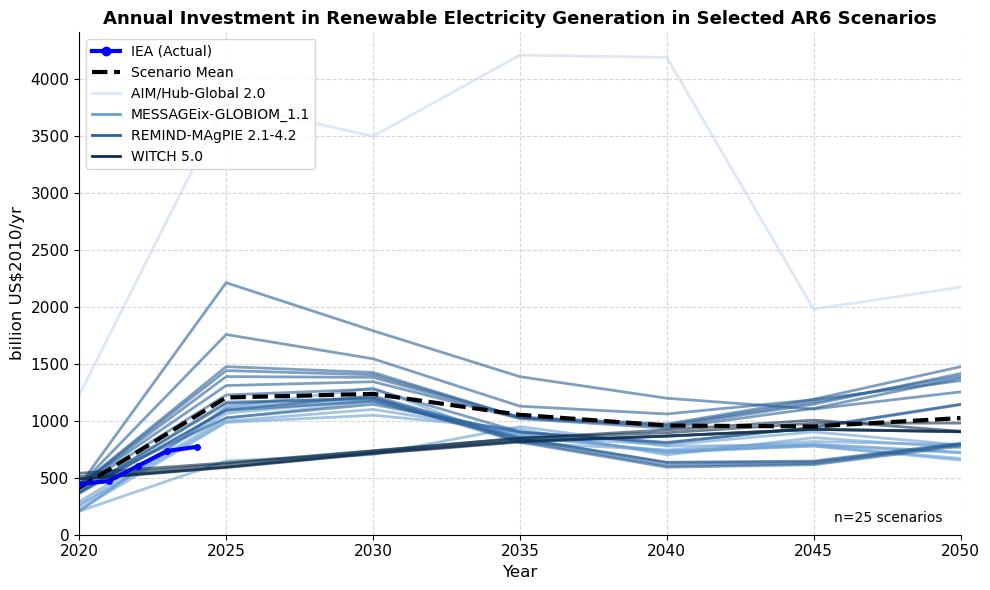

In [36]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.lines import Line2D
import matplotlib.patches as mpatches

# --- Constants ---
FIG_SIZE = (10, 6)
LINE_WIDTH = 2
SCENARIO_ALPHA = 0.6
GREY_MIX_RATIO = 0.0
MEAN_COLOR = 'black'
MEAN_ALPHA = 1.0
X_START, X_END = 2020, 2050
SHOW_SHADED_REGION = False
SHADING_COLOR = 'gray'
SHADING_ALPHA = 0.15

# All possible year columns (including the new actuals)
years_str_all = ['2020', '2021', '2022', '2023', '2024', '2025', '2030', '2035', '2040', '2045', '2050']
# Desired ticks on the axis - every 5 years
ticks_years = [2020, 2025, 2030, 2035, 2040, 2045, 2050]

def get_greyed_color(color, alpha=1.0, mix_ratio=0.0):
    rgb = mcolors.to_rgb(color)
    greyed_rgb = tuple((1 - mix_ratio) * c + mix_ratio * 0.75 for c in rgb)
    return greyed_rgb + (alpha,)

MODEL_COLORS = {
    'AIM/Hub-Global 2.0':        '#C6D9F0',
    'MESSAGEix-GLOBIOM_1.1':     '#6A9FD4',
    'REMIND-MAgPIE 2.1-4.2':     '#2A6099',
    'WITCH 5.0':                 '#0D2E4E',
    'IEA':                       '#0000FF' # Added Blue for IEA Actuals
}

# --- Data Loading ---
# Updated to use the 'ACTUAL' version of the CSV
df = pd.read_csv('RE_Investment_ACTUAL.csv')

# Separate IEA actuals from AR6 scenarios for statistics
scenarios_df = df[df['Model'] != 'IEA']
iea_df = df[df['Model'] == 'IEA']
model_counts = scenarios_df['Model'].value_counts().to_dict()

plt.figure(figsize=FIG_SIZE)

# --- Plotting Scenarios ---
if SHOW_SHADED_REGION:
    p25 = scenarios_df[[str(y) for y in ticks_years]].quantile(0.25)
    p75 = scenarios_df[[str(y) for y in ticks_years]].quantile(0.75)
    plt.fill_between(ticks_years, p25, p75, color=SHADING_COLOR, alpha=SHADING_ALPHA, zorder=1)

for idx, row in scenarios_df.iterrows():
    model_name = row['Model']
    base_color = MODEL_COLORS.get(model_name, '#7f7f7f')
    line_color = get_greyed_color(base_color, alpha=SCENARIO_ALPHA, mix_ratio=GREY_MIX_RATIO)
    
    # .dropna() ensures the line connects 2020 directly to 2025 where data is missing
    series = row[years_str_all].dropna()
    plt.plot(series.index.astype(int), series.values, color=line_color, linewidth=LINE_WIDTH, zorder=2, label='_nolegend_')

# --- Plotting IEA Actuals ---
for idx, row in iea_df.iterrows():
    series = row[years_str_all].dropna()
    plt.plot(series.index.astype(int), series.values, color=MODEL_COLORS['IEA'], linewidth=3, 
             marker='o', markersize=4, zorder=15, label='_nolegend_')

# --- Plotting Mean of Scenarios ---
# Only use the major 5-year intervals for the mean line
overall_mean = scenarios_df[[str(y) for y in ticks_years]].mean()
plt.plot(ticks_years, overall_mean.values, color=MEAN_COLOR, linewidth=3, alpha=MEAN_ALPHA,
         zorder=10, label='_nolegend_', linestyle="--")

# --- Legend Setup ---
legend_elements = [
    Line2D([0], [0], color=MODEL_COLORS['IEA'], lw=3, marker='o', label='IEA (Actual)'),
    Line2D([0], [0], color=MEAN_COLOR, lw=3, alpha=MEAN_ALPHA, label='Scenario Mean', linestyle="--")
]

for model in MODEL_COLORS:
    if model != 'IEA' and model in scenarios_df['Model'].unique():
        n = model_counts.get(model, 1)
        swatch_alpha = min(SCENARIO_ALPHA * n, 1.0)
        swatch_color = get_greyed_color(MODEL_COLORS[model], alpha=swatch_alpha, mix_ratio=GREY_MIX_RATIO)
        legend_elements.append(Line2D([0], [0], color=swatch_color, lw=LINE_WIDTH, label=model))

if SHOW_SHADED_REGION:
    legend_elements.append(mpatches.Patch(color=SHADING_COLOR, alpha=SHADING_ALPHA, label='25th-75th Percentile'))

# --- Formatting ---
unit = df['Unit'].iloc[0]
plt.title('Annual Investment in Renewable Electricity Generation in Selected AR6 Scenarios', fontsize=13, fontweight='bold')
plt.xlabel('Year', fontsize=12)
plt.ylabel(unit, fontsize=12)

# Specific X-ticks only every 5 years
plt.xticks(ticks_years, fontsize=11)
plt.yticks(fontsize=11)
plt.xlim(X_START, X_END)
plt.ylim(bottom=0)
plt.grid(True, linestyle='--', alpha=0.5)

plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

plt.legend(handles=legend_elements, loc='upper left', fontsize=10)
plt.annotate(f'n={len(scenarios_df)} scenarios', xy=(0.98, 0.02), xycoords='axes fraction',
             fontsize=10, color='black', ha='right', va='bottom')

plt.tight_layout()
plt.savefig('RE_investment_fixed.svg', format='svg', bbox_inches='tight', transparent=True)
plt.show()

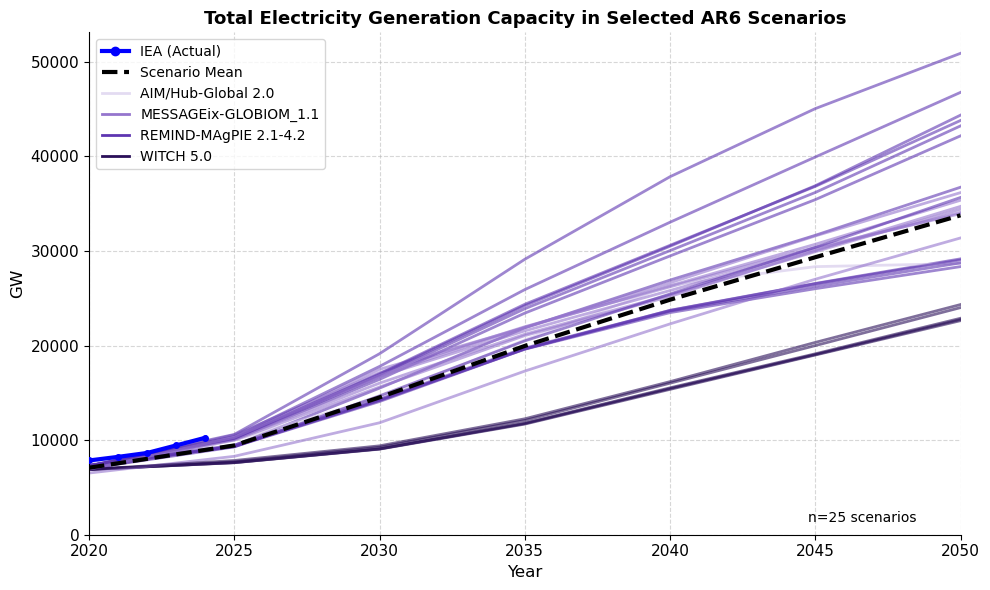

In [37]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.lines import Line2D
import matplotlib.patches as mpatches

# --- Constants ---
FIG_SIZE = (10, 6)
LINE_WIDTH = 2
SCENARIO_ALPHA = 0.6
GREY_MIX_RATIO = 0.0
MEAN_COLOR = 'black'
MEAN_ALPHA = 1.0
X_START, X_END = 2020, 2050
SHOW_SHADED_REGION = False
SHADING_COLOR = 'gray'
SHADING_ALPHA = 0.15

# All possible year columns (including the new actuals)
years_str_all = ['2020', '2021', '2022', '2023', '2024', '2025', '2030', '2035', '2040', '2045', '2050']
# Desired ticks on the axis - every 5 years
ticks_years = [2020, 2025, 2030, 2035, 2040, 2045, 2050]

def get_greyed_color(color, alpha=1.0, mix_ratio=0.0):
    rgb = mcolors.to_rgb(color)
    greyed_rgb = tuple((1 - mix_ratio) * c + mix_ratio * 0.75 for c in rgb)
    return greyed_rgb + (alpha,)

MODEL_COLORS = {
    'AIM/Hub-Global 2.0':        '#D1C4E9',
    'MESSAGEix-GLOBIOM_1.1':     '#9575CD',
    'REMIND-MAgPIE 2.1-4.2':     '#5E35B1',
    'WITCH 5.0':                 '#2A1059',
    'IEA':                       '#0000FF'
}

# --- Data Loading ---
df = pd.read_csv('total_capacity_ACTUAL.csv')

# Separate IEA actuals from AR6 scenarios for statistics
scenarios_df = df[df['Model'] != 'IEA']
iea_df = df[df['Model'] == 'IEA']
model_counts = scenarios_df['Model'].value_counts().to_dict()

plt.figure(figsize=FIG_SIZE)

# --- Plotting Scenarios ---
if SHOW_SHADED_REGION:
    p25 = scenarios_df[[str(y) for y in ticks_years]].quantile(0.25)
    p75 = scenarios_df[[str(y) for y in ticks_years]].quantile(0.75)
    plt.fill_between(ticks_years, p25, p75, color=SHADING_COLOR, alpha=SHADING_ALPHA, zorder=1)

for idx, row in scenarios_df.iterrows():
    model_name = row['Model']
    base_color = MODEL_COLORS.get(model_name, '#7f7f7f')
    line_color = get_greyed_color(base_color, alpha=SCENARIO_ALPHA, mix_ratio=GREY_MIX_RATIO)
    
    # .dropna() ensures the line connects 2020 directly to 2025 where data is missing
    series = row[years_str_all].dropna()
    plt.plot(series.index.astype(int), series.values, color=line_color, linewidth=LINE_WIDTH, zorder=2, label='_nolegend_')

# --- Plotting IEA Actuals ---
for idx, row in iea_df.iterrows():
    series = row[years_str_all].dropna()
    plt.plot(series.index.astype(int), series.values, color=MODEL_COLORS['IEA'], linewidth=3, 
             marker='o', markersize=4, zorder=15, label='_nolegend_')

# --- Plotting Mean of Scenarios ---
# Only use the major 5-year intervals for the mean line
overall_mean = scenarios_df[[str(y) for y in ticks_years]].mean()
plt.plot(ticks_years, overall_mean.values, color=MEAN_COLOR, linewidth=3, alpha=MEAN_ALPHA,
         zorder=10, label='_nolegend_', linestyle="--")

# --- Legend Setup ---
legend_elements = [
    Line2D([0], [0], color=MODEL_COLORS['IEA'], lw=3, marker='o', label='IEA (Actual)'),
    Line2D([0], [0], color=MEAN_COLOR, lw=3, alpha=MEAN_ALPHA, label='Scenario Mean', linestyle="--")
]

for model in MODEL_COLORS:
    if model != 'IEA' and model in scenarios_df['Model'].unique():
        n = model_counts.get(model, 1)
        swatch_alpha = min(SCENARIO_ALPHA * n, 1.0)
        swatch_color = get_greyed_color(MODEL_COLORS[model], alpha=swatch_alpha, mix_ratio=GREY_MIX_RATIO)
        legend_elements.append(Line2D([0], [0], color=swatch_color, lw=LINE_WIDTH, label=model))

if SHOW_SHADED_REGION:
    legend_elements.append(mpatches.Patch(color=SHADING_COLOR, alpha=SHADING_ALPHA, label='25th-75th Percentile'))

# --- Formatting ---
unit = df['Unit'].iloc[0]
plt.title('Total Electricity Generation Capacity in Selected AR6 Scenarios', fontsize=13, fontweight='bold')
plt.xlabel('Year', fontsize=12)
plt.ylabel(unit, fontsize=12)

# Specific X-ticks only every 5 years
plt.xticks(ticks_years, fontsize=11)
plt.yticks(fontsize=11)
plt.xlim(X_START, X_END)
plt.ylim(bottom=0)
plt.grid(True, linestyle='--', alpha=0.5)

plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

# Positioned legend upper left for growth curves
plt.legend(handles=legend_elements, loc='upper left', fontsize=10)
plt.annotate(f'n={len(scenarios_df)} scenarios', xy=(0.95, 0.02), xycoords='axes fraction',
             fontsize=10, color='black', ha='right', va='bottom')

plt.tight_layout()
plt.savefig('total_capacity_with_IEA.png', dpi=300, bbox_inches='tight')
plt.show()

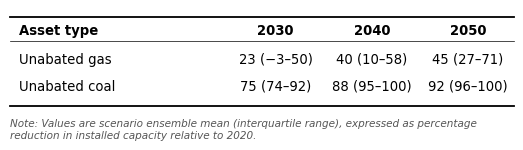

In [38]:
import pandas as pd
import matplotlib.pyplot as plt


# ── 1. Data Processing ──────────────────────────────────────────────
def get_asset_reductions(file_name, asset_label):
    df = pd.read_csv(file_name)
    scenarios = df[df['Model'] != 'IEA']

    results = {}
    for yr in ['2030', '2040', '2050']:
        red = (1 - (scenarios[yr] / scenarios['2020'])) * 100
        mean = red.mean()
        p25 = red.quantile(0.25)
        p75 = red.quantile(0.75)
        lo, hi = sorted([p25, p75])

        def fmt_num(v):
            return f"\u2212{abs(v):.0f}" if v < 0 else f"{v:.0f}"

        results[yr] = f"{fmt_num(mean)} ({fmt_num(lo)}\u2013{fmt_num(hi)})"
    return asset_label, results

gas_label, gas = get_asset_reductions('gas_wo_CCS_ACTUAL.csv', 'Unabated gas')
coal_label, coal = get_asset_reductions('coal_wo_CCS_ACTUAL.csv', 'Unabated coal')

# ── 2. Build table ──────────────────────────────────────────────────
plt.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["DejaVu Sans"],
})

fig, ax = plt.subplots(figsize=(6.5, 1.5))
ax.set_xlim(0, 11)
ax.set_ylim(0, 3.6)
ax.axis('off')

x0 = 0.2
x_data = [5.8, 7.9, 10.0]

heavy = dict(color='black', linewidth=1.3, clip_on=False)
thin  = dict(color='black', linewidth=0.5, clip_on=False)

ax.plot([0, 11], [3.35, 3.35], **heavy)   # toprule
ax.plot([0, 11], [2.6, 2.6],   **thin)    # midrule
ax.plot([0, 11], [0.6, 0.6],   **heavy)   # bottomrule

# ── Header ──
hy = 2.95
ax.text(x0, hy, 'Asset type', fontsize=9.5, fontweight='bold',
        ha='left', va='center')
for x, yr in zip(x_data, ['2030', '2040', '2050']):
    ax.text(x, hy, yr, fontsize=9.5, fontweight='bold',
            ha='center', va='center')

# ── Data ──
rows = [(gas_label, gas), (coal_label, coal)]
row_ys = [2.05, 1.2]

for (label, vals), y in zip(rows, row_ys):
    ax.text(x0, y, label, fontsize=9.5, ha='left', va='center')
    for x, yr in zip(x_data, ['2030', '2040', '2050']):
        ax.text(x, y, vals[yr], fontsize=9.5, ha='center', va='center')

# ── Footnote ──
note = ('Note: Values are scenario ensemble mean (interquartile range), '
        'expressed as percentage \nreduction in installed capacity relative to 2020.')
ax.text(0, 0.2, note, fontsize=7.5, fontstyle='italic', ha='left', va='top',
        color='#555555')

plt.savefig('journal_table_final.svg', bbox_inches='tight',
            facecolor='white')
plt.show()

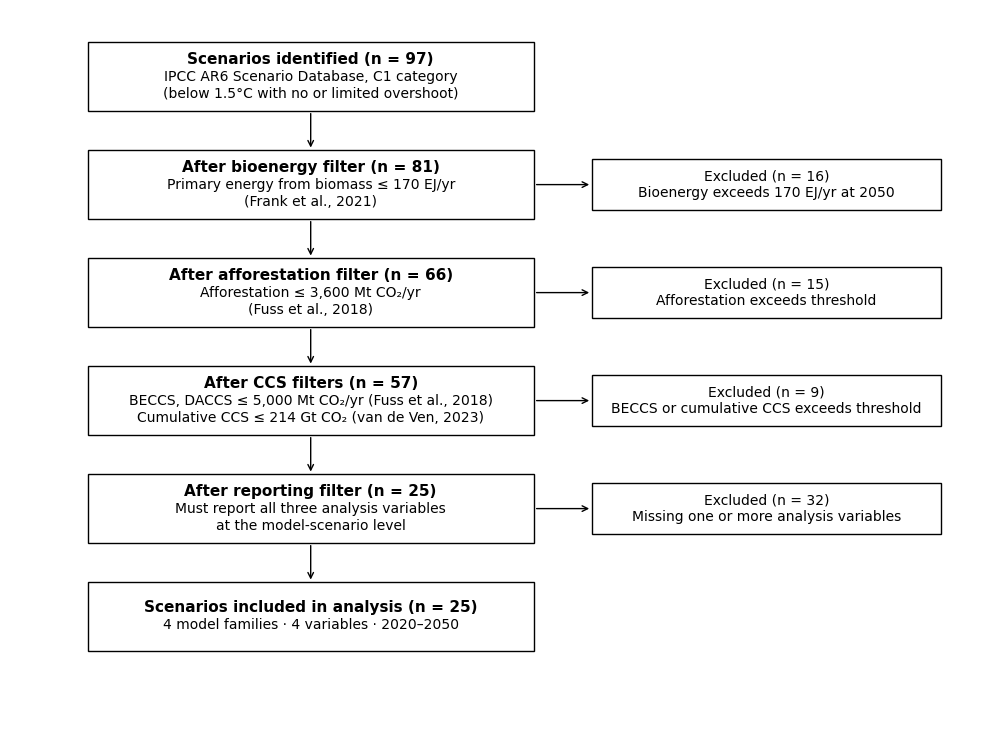

In [39]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

fig, ax = plt.subplots(figsize=(10, 7.5))
ax.set_xlim(0, 10)
ax.set_ylim(0, 10)
ax.axis('off')

# --- Style ---
box_fc = 'white'
box_ec = 'black'
box_lw = 1.0
arrow_color = 'black'
arrow_lw = 1.0
font_family = 'sans-serif'
font_size_bold = 11
font_size_body = 10

# --- Layout ---
main_w = 4.6
main_h = 0.95
main_x = 0.8
excl_w = 3.6
excl_h = 0.7
excl_x = main_x + main_w + 0.6

# Y positions — tighter vertical spacing
ys = [8.6, 7.1, 5.6, 4.1, 2.6, 1.1]


def draw_box(x, y, w, h, lines, bold_line=None):
    rect = mpatches.FancyBboxPatch(
        (x, y), w, h,
        boxstyle="square,pad=0",
        facecolor=box_fc, edgecolor=box_ec, linewidth=box_lw)
    ax.add_patch(rect)
    total_lines = (1 if bold_line else 0) + len(lines)
    line_spacing = 0.24
    start_y = y + h / 2 + (total_lines - 1) * line_spacing / 2
    i = 0
    if bold_line:
        ax.text(x + w / 2, start_y - i * line_spacing, bold_line,
                ha='center', va='center', fontsize=font_size_bold,
                fontweight='bold', family=font_family)
        i += 1
    for line in lines:
        ax.text(x + w / 2, start_y - i * line_spacing, line,
                ha='center', va='center', fontsize=font_size_body,
                family=font_family)
        i += 1


def draw_excl_box(y_main, lines):
    ey = y_main + (main_h - excl_h) / 2
    rect = mpatches.FancyBboxPatch(
        (excl_x, ey), excl_w, excl_h,
        boxstyle="square,pad=0",
        facecolor=box_fc, edgecolor=box_ec, linewidth=box_lw)
    ax.add_patch(rect)
    line_spacing = 0.22
    start_y = ey + excl_h / 2 + (len(lines) - 1) * line_spacing / 2
    for i, line in enumerate(lines):
        ax.text(excl_x + excl_w / 2, start_y - i * line_spacing, line,
                ha='center', va='center', fontsize=font_size_body,
                family=font_family)


def arrow_down(y_from, y_to):
    ax.annotate('',
                xy=(main_x + main_w / 2, y_to + main_h),
                xytext=(main_x + main_w / 2, y_from),
                arrowprops=dict(arrowstyle='->', color=arrow_color, lw=arrow_lw))


def arrow_right(y_main):
    mid_y = y_main + main_h / 2
    ax.annotate('',
                xy=(excl_x, mid_y),
                xytext=(main_x + main_w, mid_y),
                arrowprops=dict(arrowstyle='->', color=arrow_color, lw=arrow_lw))


# === Box 0: Identification ===
draw_box(main_x, ys[0], main_w, main_h,
         bold_line='Scenarios identified (n = 97)',
         lines=['IPCC AR6 Scenario Database, C1 category',
                '(below 1.5\u00B0C with no or limited overshoot)'])
arrow_down(ys[0], ys[1])

# === Box 1: C1 ===
draw_box(main_x, ys[1], main_w, main_h,
         bold_line='After bioenergy filter (n = 81)',
         lines=['Primary energy from biomass \u2264 170 EJ/yr',
                '(Frank et al., 2021)'])
arrow_right(ys[1])
draw_excl_box(ys[1],
              ['Excluded (n = 16)',
               'Bioenergy exceeds 170 EJ/yr at 2050'])
arrow_down(ys[1], ys[2])

# === Box 2: C2 ===
draw_box(main_x, ys[2], main_w, main_h,
         bold_line='After afforestation filter (n = 66)',
         lines=['Afforestation \u2264 3,600 Mt CO\u2082/yr',
                '(Fuss et al., 2018)'])
arrow_right(ys[2])
draw_excl_box(ys[2],
              ['Excluded (n = 15)',
               'Afforestation exceeds threshold'])
arrow_down(ys[2], ys[3])

# === Box 3: C3-C5 ===
draw_box(main_x, ys[3], main_w, main_h,
         bold_line='After CCS filters (n = 57)',
         lines=['BECCS, DACCS \u2264 5,000 Mt CO\u2082/yr (Fuss et al., 2018)',
                'Cumulative CCS \u2264 214 Gt CO\u2082 (van de Ven, 2023)'])
arrow_right(ys[3])
draw_excl_box(ys[3],
              ['Excluded (n = 9)',
               'BECCS or cumulative CCS exceeds threshold'])
arrow_down(ys[3], ys[4])

# === Box 4: H ===
draw_box(main_x, ys[4], main_w, main_h,
         bold_line='After reporting filter (n = 25)',
         lines=['Must report all three analysis variables',
                'at the model-scenario level'])
arrow_right(ys[4])
draw_excl_box(ys[4],
              ['Excluded (n = 32)',
               'Missing one or more analysis variables'])
arrow_down(ys[4], ys[5])

# === Box 5: Included ===
draw_box(main_x, ys[5], main_w, main_h,
         bold_line='Scenarios included in analysis (n = 25)',
         lines=['4 model families \u00B7 4 variables \u00B7 2020\u20132050'])

plt.tight_layout()
plt.savefig('prisma_scenario_filtering.svg', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()